# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2098]:
from pipeline.CombinedDeconvolveGeneExpressionRunner \
    import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'

runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)


In [2102]:
from src.config import load_cloccs_configs
config1, config2 = load_cloccs_configs()

In [2103]:
def gene_alpha_search(gene_name, kappa, replicate, alphas=None):

    solutions = []
    print(f"Searching replicate {replicate } alphas: {gene_name}...")

    for alpha in alphas:
        print(alpha, end=",")
        if replicate == 1:
            runner.config1.modify_alpha(alpha)
        elif replicate == 2:
            runner.config2.modify_alpha(alpha)
        find_gamma = runner.deconvolve_gene_find_gamma(gene_name, kappa=kappa,
            replicate=replicate)   
    
        solution = find_gamma.retrieve_solution()
        solutions.append(solution)
    print()

    df = pd.DataFrame(solutions, index=alphas)
    df.index.name = 'alpha'
    df['gene'] = gene_name
    df['replicate'] = replicate
    df = df.reset_index().set_index(['replicate', 'alpha', 'gene'])
    
    return df


In [ ]:
from src.timer import Timer
timer = Timer()
alphas = np.arange(4, 49, 16)
print("Number of alphas: ", len(alphas))

gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4']#
#    'ASH1', 'EGT2', 'AMN1', 'PRY3', 'SCW11', 'CTS1']

solutions = []
for replicate in [1, 2]:
    for gene_name in gene_names:
        solution_result = gene_alpha_search(gene_name, kappa=0.0, 
                                          replicate=replicate, alphas=alphas)
        solutions.append(solution_result)
        timer.print_time()

all_alpha_results_df = pd.concat(solutions)

Number of alphas:  3
Searching replicate 1 alphas: DSE1...
4,20,36,
00:02:01.860
Searching replicate 1 alphas: DSE2...
4,20,36,
00:04:02.788
Searching replicate 1 alphas: DSE3...
4,20,36,
00:06:04.146
Searching replicate 1 alphas: DSE4...
4,20,36,
00:08:06.865
Searching replicate 2 alphas: DSE1...
4,20,36,
00:10:00.514
Searching replicate 2 alphas: DSE2...
4,20,36,
00:11:58.776
Searching replicate 2 alphas: DSE3...
4,20,36,
00:14:00.617
Searching replicate 2 alphas: DSE4...
4,20,

In [ ]:
from src.alpha_search import plot_alpha_genes_subplots

In [ ]:
from src.utils import mkdir_safe
from src.figure_configs import save_figure_for_paper
save_dir = f"{output_directory}/alpha_search"

mkdir_safe(save_dir)

In [ ]:
plot_alphas = alphas#np.arange(4, 48, 8)
fig = plot_alpha_genes_subplots(config1, plot_alphas, all_alpha_results_df, 1)

all_alpha_results_df.to_csv(f"{save_dir}/alphas_repl1.csv")
save_figure_for_paper(f"{save_dir}/alphas_repl1.png", dpi=80)


In [ ]:
fig = plot_alpha_genes_subplots(config2, plot_alphas, all_alpha_results_df, 2)

all_alpha_results_df.to_csv(f"{save_dir}/alphas_repl2.csv")
save_figure_for_paper(f"{save_dir}/alphas_repl2.png", dpi=80)

In [ ]:
runner.config1.modify_alpha(30)

In [ ]:
runner.config1.plot_H()

In [2075]:
runner.deconvolve_gene_find_gamma('CLB2', replicate=1)

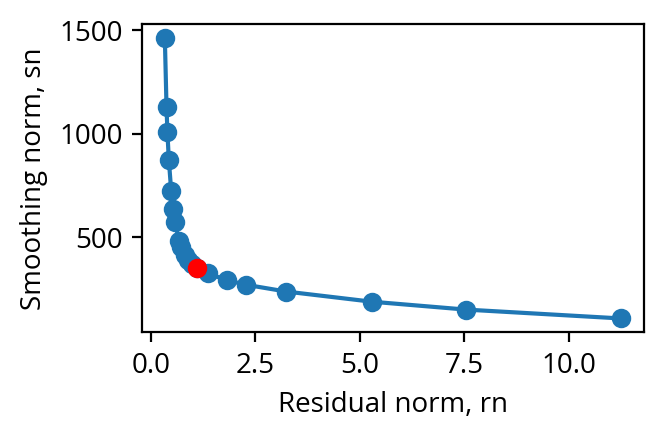

In [2076]:
runner.expression_find_gamma.gamma_optimizer.plot_elbow()

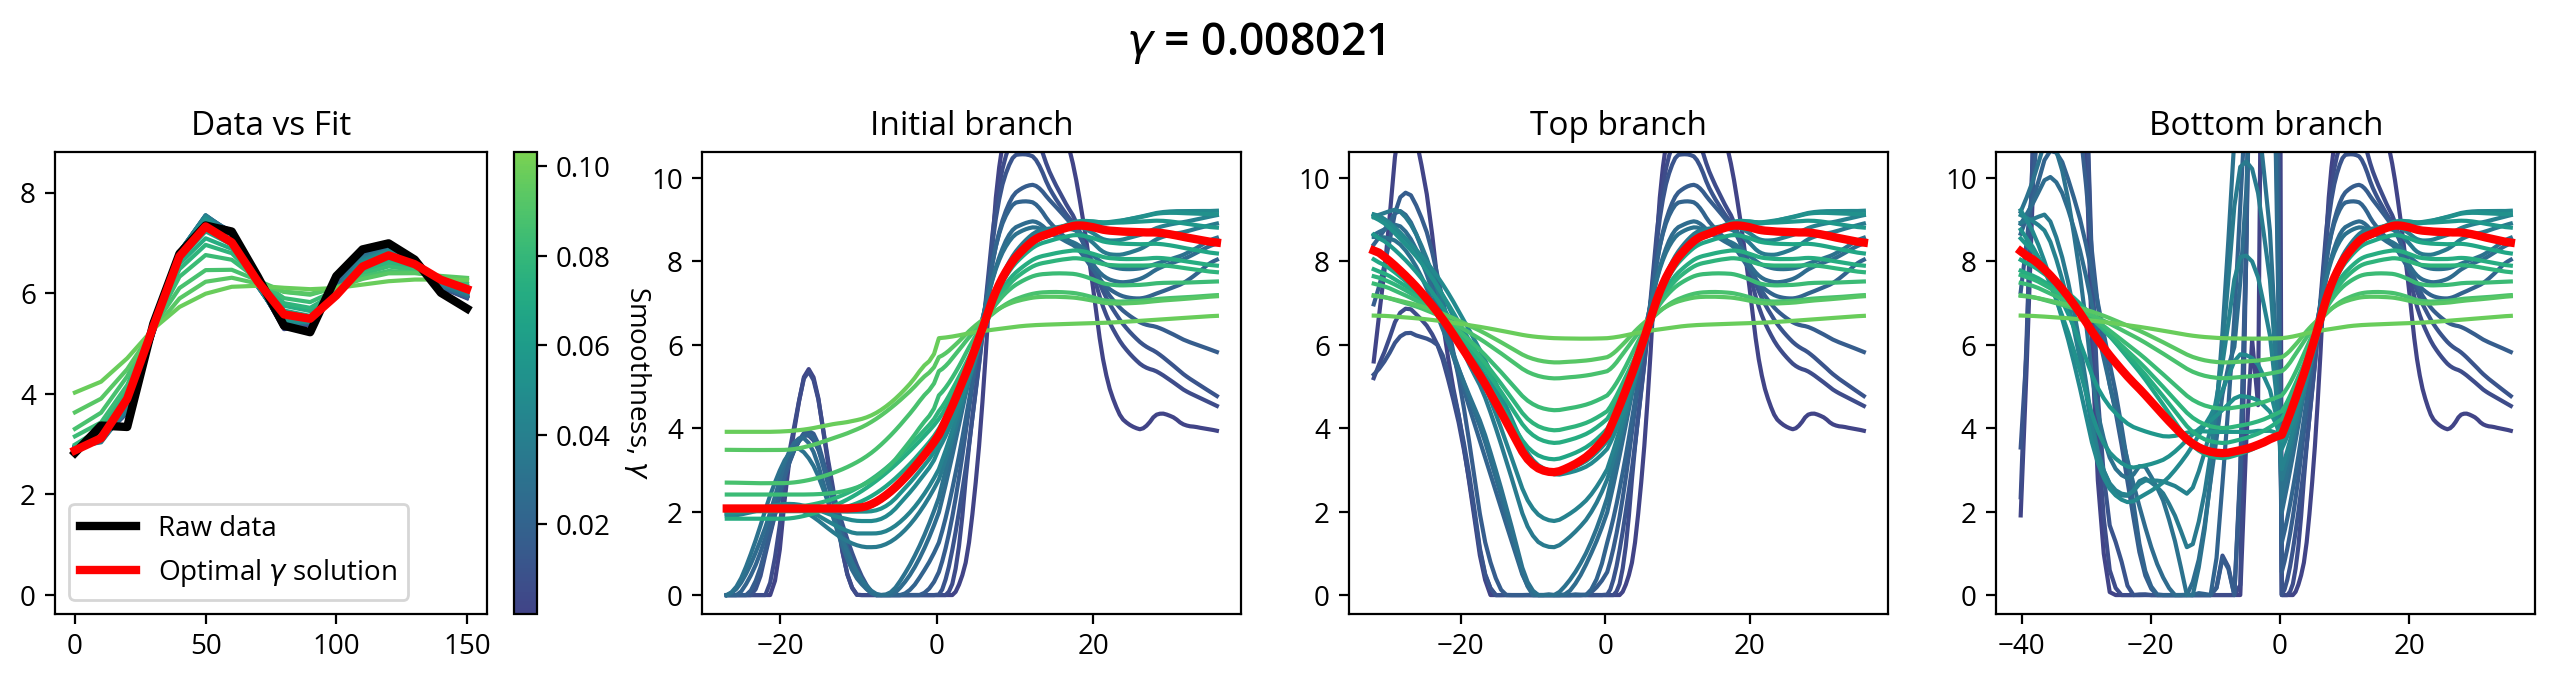

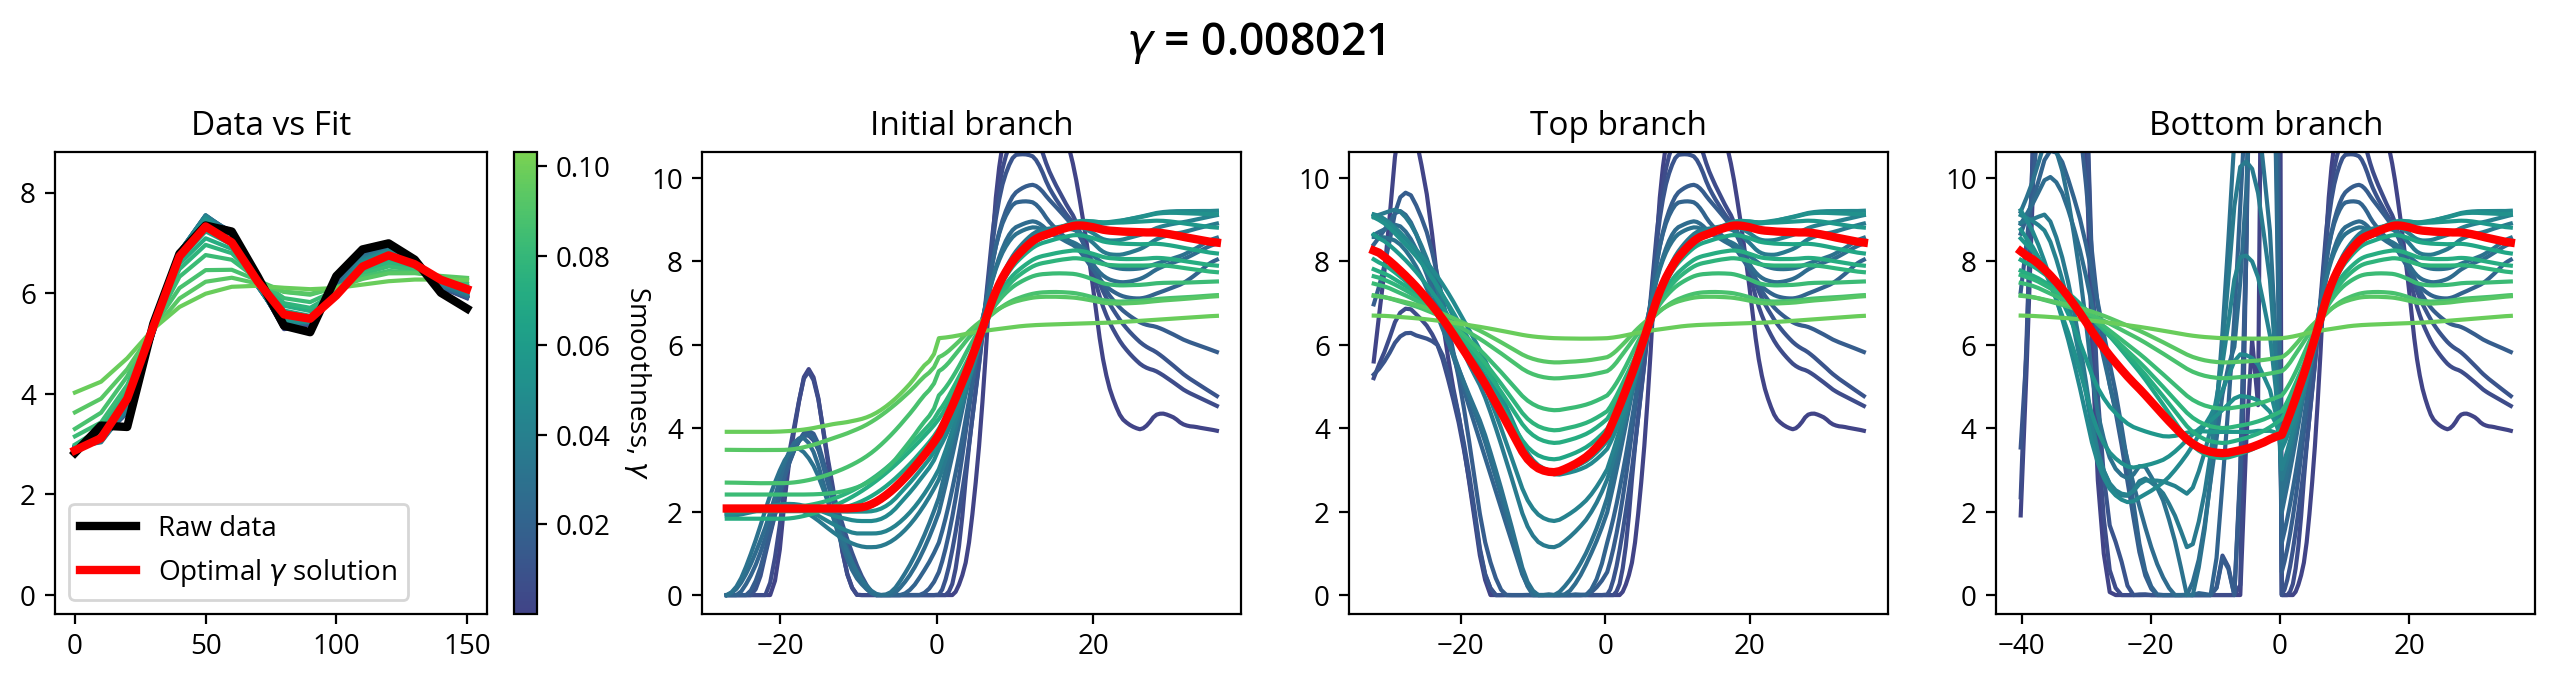

In [2077]:
runner.expression_find_gamma.plot_gamma_sweep()

In [2097]:
runner.config2.g1_num_tps, runner.config2.postg1_num_tps

(72, -8)

In [2095]:
runner.config2.modify_alpha(36)

ValueError: Number of samples, -7, must be non-negative.

In [2078]:
# Last check does the number of indices help?
from src.deconvolution_solver import DeconvolutionSolver

config = runner.expression_find_gamma.deconvolution_solver.config

test_solver = DeconvolutionSolver(config,
    runner.expression_find_gamma.deconvolution_solver.g,
    config.H, 0.008, kappa=0.0)
test_solver.verbose=True
test_solver.deconvolve()


Fit norm: 1.1107804844531368
Smoothing norm: 349.92353652015595
Initial smoothing result:  86.4084982594585
Top smoothing result:  88.17021843592049
Bottom smoothing result:  88.93632156531848


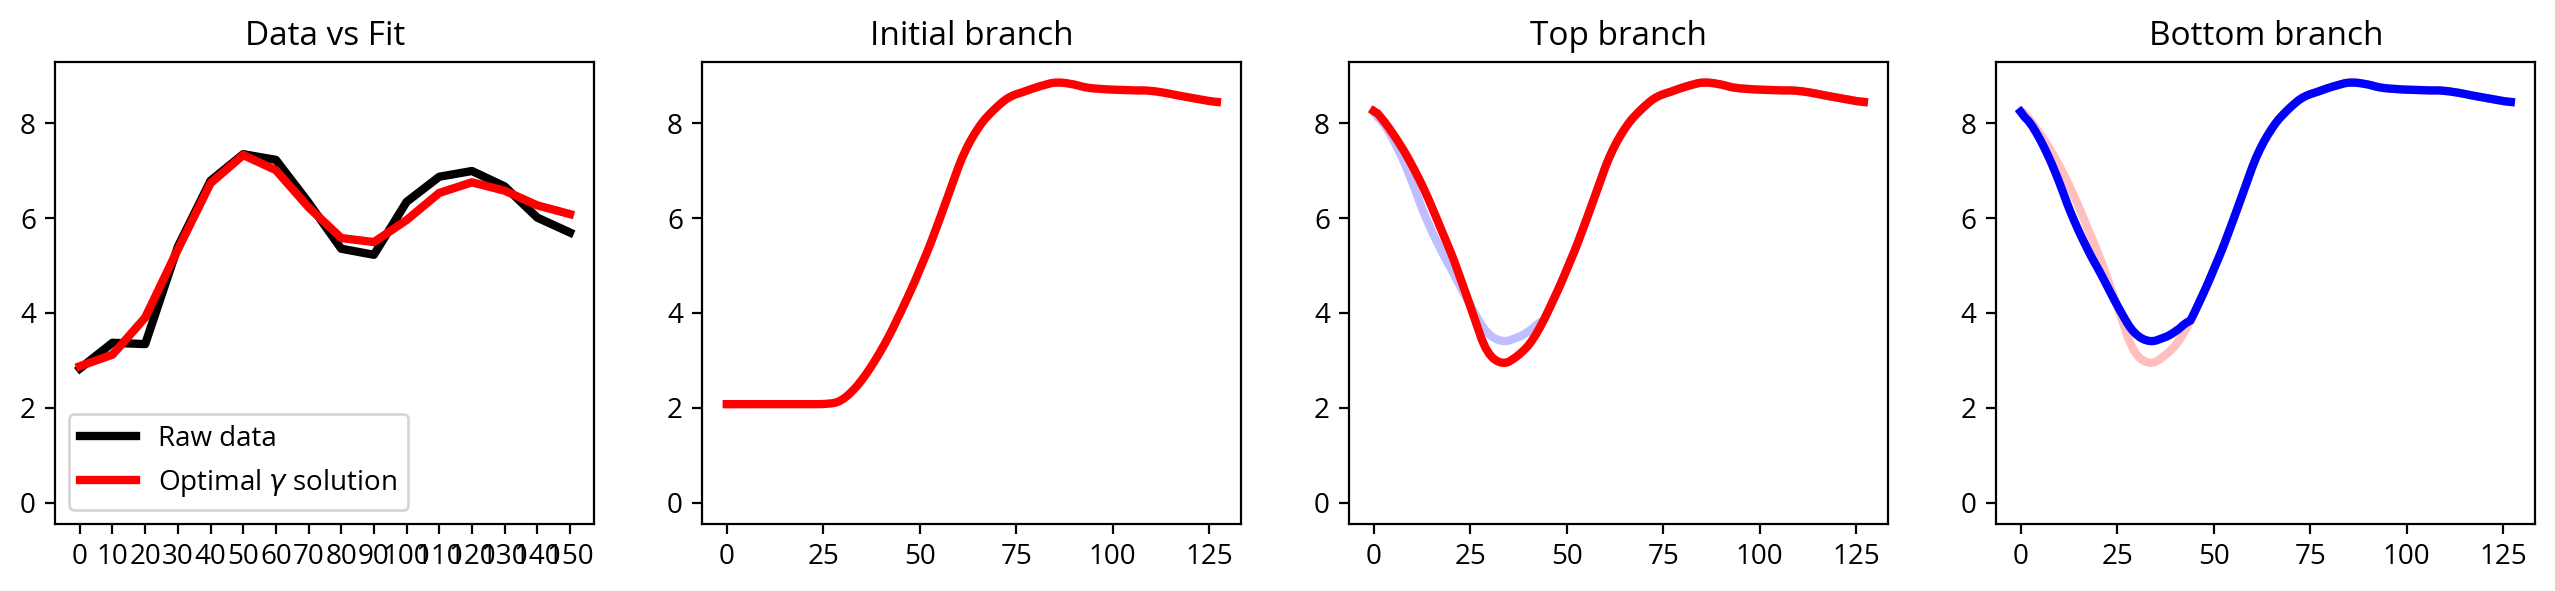

In [2079]:
test_solver.plot_fit()